# PART 9

Haikal Ali_1103223071_TK46GAB

# Chapter 9 — Orthogonal Matrices and QR Decomposition



## Orthogonal Matrices

Matriks orthogonal adalah matriks khusus yang kolom-kolomnya memenuhi dua syarat:

1. Semua kolom saling orthogonal.
2. Setiap kolom memiliki norm sama dengan 1.

Secara matematis, sifat utamanya adalah:

\[
Q^TQ = I
\]

Artinya, transpose dari matriks orthogonal berperan sebagai inversnya:

\[
Q^{-1} = Q^T
\]

Ini penting karena transpose jauh lebih mudah dan stabil dihitung dibandingkan invers matriks biasa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
Q1 = np.array([[1, -1], [1, 1]]) / np.sqrt(2)
Q2 = np.array([[1, 2, 2], [2, 1, -2], [-2, 2, -1]]) / 3

print("Q1.T @ Q1:")
print(Q1.T @ Q1)

print("\nQ2.T @ Q2:")
print(Q2.T @ Q2)

print("\nQ1 @ Q1.T:")
print(Q1 @ Q1.T)

print("\nQ2 @ Q2.T:")
print(Q2 @ Q2.T)

Q1.T @ Q1:
[[1. 0.]
 [0. 1.]]

Q2.T @ Q2:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Q1 @ Q1.T:
[[ 1. -0.]
 [-0.  1.]]

Q2 @ Q2.T:
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]


## Gram-Schmidt

Gram-Schmidt adalah prosedur untuk mengubah matriks non-orthogonal menjadi matriks orthogonal.

Idenya:
1. Ambil kolom pertama, lalu normalkan menjadi unit vector.
2. Untuk kolom berikutnya, buang komponen yang searah dengan kolom-kolom sebelumnya.
3. Normalkan hasilnya.
4. Ulangi sampai semua kolom diproses.

Gram-Schmidt penting untuk memahami konsep QR decomposition, walaupun implementasi numerik modern biasanya memakai metode yang lebih stabil.

## QR Decomposition

QR decomposition memecah matriks \(A\) menjadi:

\[
A = QR
\]

dengan:
- \(Q\): matriks orthogonal.
- \(R\): matriks upper-triangular.

Di Python, QR decomposition dapat dihitung dengan `np.linalg.qr()`.

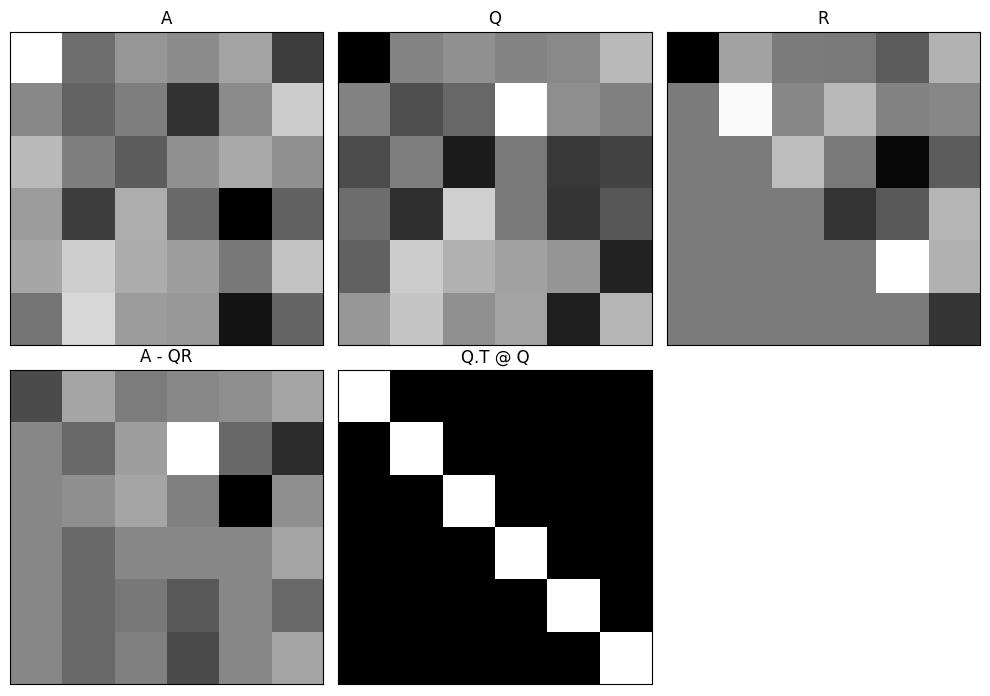

Apakah A ≈ Q @ R? True
Apakah Q.T @ Q ≈ I? True


In [3]:
A = np.random.randn(6, 6)
Q, R = np.linalg.qr(A)

fig, axs = plt.subplots(2, 3, figsize=(10, 7))

items = [
  (A, "A"),
  (Q, "Q"),
  (R, "R"),
  (A - Q @ R, "A - QR"),
  (Q.T @ Q, "Q.T @ Q")
]

for ax, (mat, title) in zip(axs.flat, items):
  im = ax.imshow(mat, cmap="gray")
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

axs.flat[-1].axis("off")
plt.tight_layout()
plt.show()

print("Apakah A ≈ Q @ R?", np.allclose(A, Q @ R))
print("Apakah Q.T @ Q ≈ I?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))

## Ukuran Q dan R

Ukuran \(Q\) dan \(R\) bergantung pada ukuran matriks awal \(A\), serta apakah QR decomposition yang digunakan adalah mode `reduced` atau `complete`.

Untuk matriks tinggi, QR decomposition dapat menghasilkan:
- `reduced`: \(Q\) berukuran sama tinggi dengan \(A\), tetapi jumlah kolomnya mengikuti jumlah kolom \(A\).
- `complete`: \(Q\) dibuat square.

In [4]:
A = np.array([[1, -1]]).T

Q_reduced, R_reduced = np.linalg.qr(A, mode="reduced")
Q_complete, R_complete = np.linalg.qr(A, mode="complete")

print("A shape:", A.shape)

print("\nReduced QR:")
print("Q shape:", Q_reduced.shape)
print("R shape:", R_reduced.shape)

print("\nComplete QR:")
print("Q shape:", Q_complete.shape)
print("R shape:", R_complete.shape)

print("\nQ complete dikalikan sqrt(2):")
print(Q_complete * np.sqrt(2))

A shape: (2, 1)

Reduced QR:
Q shape: (2, 1)
R shape: (1, 1)

Complete QR:
Q shape: (2, 2)
R shape: (2, 1)

Q complete dikalikan sqrt(2):
[[-1.  1.]
 [ 1.  1.]]


## QR dan Invers

QR decomposition dapat digunakan untuk menghitung invers secara lebih stabil.

Jika:

\[
A = QR
\]

maka:

\[
A^{-1} = R^{-1}Q^T
\]

Karena \(Q^{-1} = Q^T\), kita tidak perlu menghitung invers \(Q\).

In [5]:
A = np.random.randn(5, 5)
Q, R = np.linalg.qr(A)

Ainv_qr = np.linalg.inv(R) @ Q.T
Ainv_np = np.linalg.inv(A)

print("Error QR inverse:", np.linalg.norm(A @ Ainv_qr - np.eye(A.shape[0])))
print("Error NumPy inverse:", np.linalg.norm(A @ Ainv_np - np.eye(A.shape[0])))
print("Apakah hasil invers QR ≈ np.linalg.inv?", np.allclose(Ainv_qr, Ainv_np))

Error QR inverse: 1.7631316532123546e-15
Error NumPy inverse: 6.557021166006184e-16
Apakah hasil invers QR ≈ np.linalg.inv? True


# Code Exercises

## Exercise 9-1

Tunjukkan dengan kode bahwa untuk matriks orthogonal square berlaku:

\[
Q^TQ = QQ^T = Q^{-1}Q = QQ^{-1} = I
\]

In [6]:
A = np.random.randn(6, 6)
Q, R = np.linalg.qr(A)
Qinv = np.linalg.inv(Q)
I = np.eye(Q.shape[0])

exprs = {
  "Q.T @ Q": Q.T @ Q,
  "Q @ Q.T": Q @ Q.T,
  "Qinv @ Q": Qinv @ Q,
  "Q @ Qinv": Q @ Qinv
}

for name, result in exprs.items():
  print(name)
  print(result)
  print("Mendekati identity:", np.allclose(result, I))
  print()

Q.T @ Q
[[ 1. -0.  0.  0. -0. -0.]
 [-0.  1. -0. -0. -0. -0.]
 [ 0. -0.  1. -0. -0.  0.]
 [ 0. -0. -0.  1.  0.  0.]
 [-0. -0. -0.  0.  1. -0.]
 [-0. -0.  0.  0. -0.  1.]]
Mendekati identity: True

Q @ Q.T
[[ 1. -0. -0.  0.  0. -0.]
 [-0.  1. -0.  0. -0.  0.]
 [-0. -0.  1. -0.  0.  0.]
 [ 0.  0. -0.  1. -0.  0.]
 [ 0. -0.  0. -0.  1. -0.]
 [-0.  0.  0.  0. -0.  1.]]
Mendekati identity: True

Qinv @ Q
[[ 1.  0. -0. -0.  0.  0.]
 [-0.  1. -0. -0. -0.  0.]
 [-0.  0.  1. -0. -0. -0.]
 [ 0. -0. -0.  1. -0.  0.]
 [-0. -0.  0. -0.  1.  0.]
 [-0. -0. -0. -0. -0.  1.]]
Mendekati identity: True

Q @ Qinv
[[ 1. -0. -0.  0.  0. -0.]
 [-0.  1.  0. -0. -0.  0.]
 [-0.  0.  1.  0. -0.  0.]
 [ 0.  0.  0.  1. -0. -0.]
 [-0.  0.  0. -0.  1.  0.]
 [-0. -0. -0.  0.  0.  1.]]
Mendekati identity: True



## Exercise 9-2

Implementasikan prosedur Gram-Schmidt untuk matriks random 4 × 4, lalu bandingkan dengan hasil `np.linalg.qr()`.

Catatan dari materi: tanda pada vektor dapat berbeda karena ada ketidakpastian tanda pada dekomposisi matriks. Karena itu, perbandingan dilakukan setelah menyesuaikan tanda kolom.

In [7]:
def gram_schmidt(V):
  V = V.astype(float)
  n_rows, n_cols = V.shape
  Q = np.zeros((n_rows, n_cols))

  for j in range(n_cols):
    v = V[:, j].copy()

    for i in range(j):
      v = v - np.dot(Q[:, i], v) * Q[:, i]

    norm_v = np.linalg.norm(v)

    if norm_v < 1e-12:
      Q[:, j] = np.zeros(n_rows)
    else:
      Q[:, j] = v / norm_v

  return Q

A = np.random.randn(4, 4)

Q_gs = gram_schmidt(A)
Q_np, R_np = np.linalg.qr(A)

Q_gs_aligned = Q_gs.copy()
for i in range(Q_gs.shape[1]):
  if np.dot(Q_gs_aligned[:, i], Q_np[:, i]) < 0:
    Q_gs_aligned[:, i] *= -1

print("Q dari Gram-Schmidt:")
print(Q_gs)

print("\nQ dari np.linalg.qr:")
print(Q_np)

print("\nMax absolute difference setelah penyesuaian tanda:")
print(np.max(np.abs(Q_gs_aligned - Q_np)))

print("\nQ_gs.T @ Q_gs:")
print(Q_gs.T @ Q_gs)

print("\nApakah Q_gs orthogonal?", np.allclose(Q_gs.T @ Q_gs, np.eye(4)))

Q dari Gram-Schmidt:
[[-0.8666 -0.2221  0.2388  0.3776]
 [-0.128   0.1198 -0.9175  0.3569]
 [ 0.3193 -0.914  -0.0706  0.2399]
 [-0.3614 -0.3176 -0.3101 -0.82  ]]

Q dari np.linalg.qr:
[[-0.8666  0.2221  0.2388 -0.3776]
 [-0.128  -0.1198 -0.9175 -0.3569]
 [ 0.3193  0.914  -0.0706 -0.2399]
 [-0.3614  0.3176 -0.3101  0.82  ]]

Max absolute difference setelah penyesuaian tanda:
4.440892098500626e-16

Q_gs.T @ Q_gs:
[[ 1. -0. -0. -0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1. -0.]
 [-0.  0. -0.  1.]]

Apakah Q_gs orthogonal? True


## Exercise 9-3

Cek QR decomposition pada matriks yang hampir orthogonal:

1. Buat matriks orthogonal \(U\) dari QR decomposition matriks random 6 × 6.
2. QR decomposition dari \(U\), lalu cek bahwa \(R = I\).
3. Ubah norm kolom-kolom \(U\) menjadi 10 sampai 15, lalu cek bahwa \(R\) menjadi diagonal dengan nilai 10 sampai 15.
4. Rusak orthogonality dengan mengubah satu elemen, lalu amati perubahan \(R\).

In [8]:
A = np.random.randn(6, 6)
U, _ = np.linalg.qr(A)

Q1, R1 = np.linalg.qr(U)

print("R dari QR(U):")
print(R1)
print("Apakah R ≈ I?", np.allclose(R1, np.eye(6)))

scales = np.arange(10, 16)
U_scaled = U * scales

Q2, R2 = np.linalg.qr(U_scaled)

print("\nDiagonal R setelah norm kolom U diubah menjadi 10 sampai 15:")
print(np.diag(R2))
print("R:")
print(R2)

print("\nQ.T @ Q:")
print(Q2.T @ Q2)
print("Apakah Q.T @ Q ≈ I?", np.allclose(Q2.T @ Q2, np.eye(6)))

U_broken = U_scaled.copy()
U_broken[0, 3] = 0

Q3, R3 = np.linalg.qr(U_broken)

print("\nR setelah orthogonality dirusak:")
print(R3)

print("\nElemen off-diagonal pada R muncul karena kolom-kolom matriks tidak lagi saling orthogonal.")

R dari QR(U):
[[ 1.  0.  0. -0. -0. -0.]
 [ 0.  1.  0.  0.  0. -0.]
 [ 0.  0.  1. -0. -0.  0.]
 [ 0.  0.  0.  1. -0.  0.]
 [ 0.  0.  0.  0.  1. -0.]
 [ 0.  0.  0.  0.  0.  1.]]
Apakah R ≈ I? True

Diagonal R setelah norm kolom U diubah menjadi 10 sampai 15:
[10. 11. 12. 13. 14. 15.]
R:
[[10.  0.  0.  0. -0. -0.]
 [ 0. 11.  0.  0. -0. -0.]
 [ 0.  0. 12. -0. -0. -0.]
 [ 0.  0.  0. 13. -0.  0.]
 [ 0.  0.  0.  0. 14. -0.]
 [ 0.  0.  0.  0.  0. 15.]]

Q.T @ Q:
[[ 1. -0. -0.  0. -0. -0.]
 [-0.  1. -0.  0. -0.  0.]
 [-0. -0.  1. -0.  0.  0.]
 [ 0.  0. -0.  1.  0.  0.]
 [-0. -0.  0.  0.  1.  0.]
 [-0.  0.  0.  0.  0.  1.]]
Apakah Q.T @ Q ≈ I? True

R setelah orthogonality dirusak:
[[10.      0.      0.      5.5195 -0.     -0.    ]
 [ 0.     11.      0.      1.255  -0.     -0.    ]
 [ 0.      0.     12.     -1.3536 -0.     -0.    ]
 [ 0.      0.      0.      9.0153  2.1552 -1.5728]
 [ 0.      0.      0.      0.     13.8331  0.245 ]
 [ 0.      0.      0.      0.      0.     14.9153]]

Elemen off

## Exercise 9-4

Bandingkan error invers menggunakan:
1. Metode old-school dari Chapter 8.
2. Metode berbasis QR.

Error dihitung sebagai jarak Euclidean dari \(AA^{-1}\) ke identity matrix.

Error old-school: 1.29793322048407e-15
Error QR: 1.3854607581640727e-15


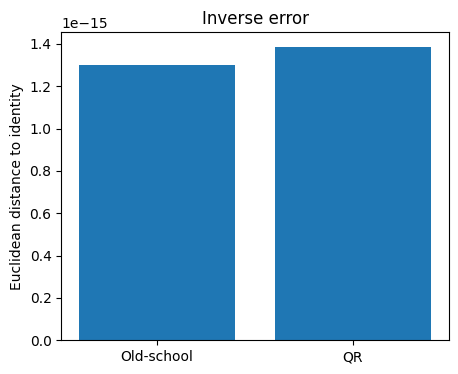

In [9]:
def old_school_inv(A):
  A = np.array(A, dtype=float)

  if A.shape[0] != A.shape[1]:
    raise ValueError("Matriks harus square.")

  if np.linalg.matrix_rank(A) < A.shape[0]:
    raise ValueError("Matriks harus full-rank.")

  n = A.shape[0]
  det_A = np.linalg.det(A)

  if np.abs(det_A) < 1e-12:
    raise ValueError("Matriks singular atau hampir singular.")

  minors = np.zeros((n, n))

  for i in range(n):
    for j in range(n):
      submatrix = np.delete(np.delete(A, i, axis=0), j, axis=1)
      minors[i, j] = np.linalg.det(submatrix)

  grid = np.fromfunction(lambda i, j: (-1) ** (i + j), (n, n))
  cofactors = minors * grid
  adjugate = cofactors.T

  return adjugate / det_A

A = np.random.randn(5, 5)

Ainv_old = old_school_inv(A)

Q, R = np.linalg.qr(A)
Rinv_old = old_school_inv(R)
Ainv_qr = Rinv_old @ Q.T

I = np.eye(A.shape[0])

err_old = np.linalg.norm(A @ Ainv_old - I)
err_qr = np.linalg.norm(A @ Ainv_qr - I)

print("Error old-school:", err_old)
print("Error QR:", err_qr)

plt.figure(figsize=(5, 4))
plt.bar(["Old-school", "QR"], [err_old, err_qr])
plt.ylabel("Euclidean distance to identity")
plt.title("Inverse error")
plt.show()

## Exercise 9-5

Ulangi eksperimen sebelumnya sebanyak 100 iterasi untuk matriks 5 × 5 dan 30 × 30.

Untuk ukuran 30 × 30, metode cofactor/minor old-school sangat berat secara komputasi. Karena itu, bagian 30 × 30 memakai `np.linalg.inv` sebagai pembanding praktis, sedangkan QR tetap dihitung dari \(R^{-1}Q^T\).

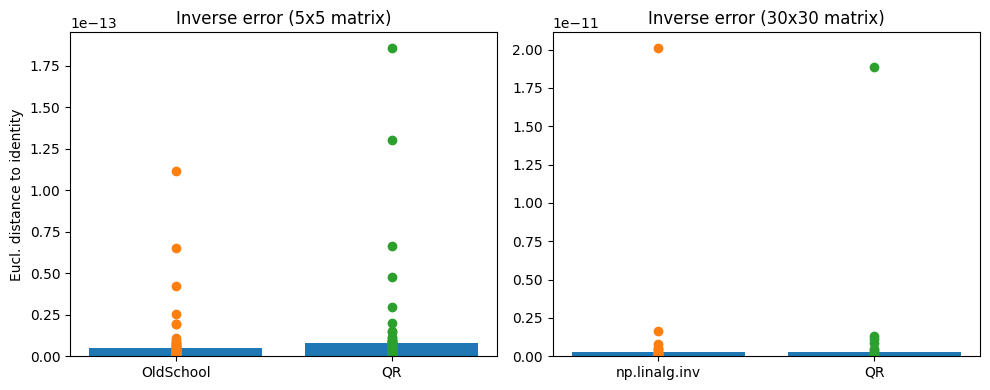

In [10]:
def inverse_error_experiment(matrix_size, n_iter=100, use_old_school=True):
  errors_old = np.zeros(n_iter)
  errors_qr = np.zeros(n_iter)

  for i in range(n_iter):
    A = np.random.randn(matrix_size, matrix_size)
    I = np.eye(matrix_size)

    if use_old_school:
      Ainv_old = old_school_inv(A)
    else:
      Ainv_old = np.linalg.inv(A)

    Q, R = np.linalg.qr(A)

    if use_old_school and matrix_size <= 5:
      Rinv = old_school_inv(R)
    else:
      Rinv = np.linalg.inv(R)

    Ainv_qr = Rinv @ Q.T

    errors_old[i] = np.linalg.norm(A @ Ainv_old - I)
    errors_qr[i] = np.linalg.norm(A @ Ainv_qr - I)

  return errors_old, errors_qr

errors_5_old, errors_5_qr = inverse_error_experiment(5, n_iter=100, use_old_school=True)
errors_30_old, errors_30_qr = inverse_error_experiment(30, n_iter=100, use_old_school=False)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].bar([0, 1], [np.mean(errors_5_old), np.mean(errors_5_qr)])
axs[0].scatter(np.zeros_like(errors_5_old), errors_5_old)
axs[0].scatter(np.ones_like(errors_5_qr), errors_5_qr)
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(["OldSchool", "QR"])
axs[0].set_title("Inverse error (5x5 matrix)")
axs[0].set_ylabel("Eucl. distance to identity")

axs[1].bar([0, 1], [np.mean(errors_30_old), np.mean(errors_30_qr)])
axs[1].scatter(np.zeros_like(errors_30_old), errors_30_old)
axs[1].scatter(np.ones_like(errors_30_qr), errors_30_qr)
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(["np.linalg.inv", "QR"])
axs[1].set_title("Inverse error (30x30 matrix)")

plt.tight_layout()
plt.show()

## Exercise 9-6

Konfirmasi sifat matriks orthogonal square:

1. Semua singular values dan eigenvalues bernilai 1.
2. Induced 2-norm bernilai 1.
3. Frobenius norm dibagi \(\sqrt{M}\) bernilai 1.
4. Matriks orthogonal dapat merotasi vektor, tetapi tidak mengubah norm vektor.

In [11]:
for M in [3, 6, 10]:
  A = np.random.randn(M, M)
  Q, R = np.linalg.qr(A)

  induced_norm = np.linalg.norm(Q, 2)
  fro_norm_scaled = np.sqrt(np.sum(Q**2)) / np.sqrt(M)

  print(f"M = {M}")
  print("Induced 2-norm:", induced_norm)
  print("Frobenius norm / sqrt(M):", fro_norm_scaled)
  print("Keduanya ≈ 1:", np.allclose(induced_norm, 1) and np.allclose(fro_norm_scaled, 1))
  print()

M = 6
A = np.random.randn(M, M)
Q, R = np.linalg.qr(A)

v = np.random.randn(M, 1)
Qv = Q @ v

print("Norm v:", np.linalg.norm(v))
print("Norm Qv:", np.linalg.norm(Qv))
print("Apakah norm v ≈ norm Qv?", np.allclose(np.linalg.norm(v), np.linalg.norm(Qv)))

M = 3
Induced 2-norm: 1.0000000000000002
Frobenius norm / sqrt(M): 1.0
Keduanya ≈ 1: True

M = 6
Induced 2-norm: 1.0000000000000004
Frobenius norm / sqrt(M): 1.0000000000000002
Keduanya ≈ 1: True

M = 10
Induced 2-norm: 1.0000000000000007
Frobenius norm / sqrt(M): 1.0
Keduanya ≈ 1: True

Norm v: 3.4059549203432127
Norm Qv: 3.4059549203432127
Apakah norm v ≈ norm Qv? True


## Exercise 9-7

Untuk matriks tinggi full column-rank \(A\), gunakan QR decomposition `complete`.

Tunjukkan bahwa:
- Baris pertama sampai \(N\) pada \(R\) membentuk matriks upper-triangular.
- Baris setelahnya adalah nol.
- Invers dari submatriks \(R\) bagian atas sama dengan kolom pertama sampai \(N\) dari pseudoinverse \(R\) tinggi.

In [12]:
A = np.random.randn(10, 4)
Q, R = np.linalg.qr(A, mode="complete")

M, N = A.shape

print("Shape A:", A.shape)
print("Shape Q:", Q.shape)
print("Shape R:", R.shape)

R_top = R[:N, :]
R_bottom = R[N:, :]

print("\nR:")
print(R)

print("\nR_top:")
print(R_top)

print("\nR_bottom:")
print(R_bottom)

print("\nApakah R_top upper-triangular?", np.allclose(R_top, np.triu(R_top)))
print("Apakah R_bottom nol?", np.allclose(R_bottom, np.zeros_like(R_bottom)))

R_top_inv = np.linalg.inv(R_top)
R_pinv = np.linalg.pinv(R)

print("\nShape inv(R_top):", R_top_inv.shape)
print("Shape pinv(R):", R_pinv.shape)

print("\nApakah inv(R_top) ≈ kolom pertama sampai N dari pinv(R)?")
print(np.allclose(R_top_inv, R_pinv[:, :N]))

print("\nEuclidean distance:")
print(np.linalg.norm(R_top_inv - R_pinv[:, :N]))

Shape A: (10, 4)
Shape Q: (10, 10)
Shape R: (10, 4)

R:
[[-3.9754  0.0788 -0.528   1.17  ]
 [ 0.     -2.4357 -0.2255 -0.4522]
 [ 0.      0.      2.3098  0.4657]
 [ 0.      0.      0.     -2.8828]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]]

R_top:
[[-3.9754  0.0788 -0.528   1.17  ]
 [ 0.     -2.4357 -0.2255 -0.4522]
 [ 0.      0.      2.3098  0.4657]
 [ 0.      0.      0.     -2.8828]]

R_bottom:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Apakah R_top upper-triangular? True
Apakah R_bottom nol? True

Shape inv(R_top): (4, 4)
Shape pinv(R): (4, 10)

Apakah inv(R_top) ≈ kolom pertama sampai N dari pinv(R)?
True

Euclidean distance:
3.0598960296369435e-16
